In [1]:
BATCH_SIZE = 64
TARGET_PROPERTY = 'em_max'
NUM_EPOCHS = 300
RANDOM_SEED = 42

## Инициализация

### Загрузка данных, функции

In [2]:
import warnings
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from statistics import mean

from fpgen.prop_prediction.dataset import FPbase
from fpgen.prop_prediction.metrics import get_regression_metrics, bootstrap_metric_ci
from fpgen.prop_prediction.models import (
    EmbeddingCNN,
    EmbeddingLSTM,
    SequenceLSTM,
    SequenceCNN
)

warnings.filterwarnings('ignore')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
torch.manual_seed(12)
np.random.seed(12)

In [5]:
dataset = FPbase()

#with open('./data/sequence.pickle', 'rb') as file:
#    seq_to_embedding = pickle.load(file)

In [7]:
#ac_dataset = FPbase('data/dataset_with_active_center.csv')

#with open('./data/sequence_with_active_center.pickle', 'rb') as file:
#    ac_seq_to_embedding = pickle.load(file)

In [8]:
(x_train, y_train), (x_val, y_val) = dataset.get_train_val(TARGET_PROPERTY, 0.2, random_state=RANDOM_SEED)
x_test, y_test = dataset.get_test(TARGET_PROPERTY)

In [ ]:
(ac_x_train, ac_y_train), (ac_x_val, ac_y_val) = dataset.get_train_val(TARGET_PROPERTY, 0.2, random_state=RANDOM_SEED)
ac_x_test, ac_y_test = ac_dataset.get_test(TARGET_PROPERTY)

In [10]:
VOCAB = {char: (i + 1) for i, char in enumerate('ACDEFGHIKLMNPRQSTVWYX')}
PAD_TOKEN = '?'
VOCAB[PAD_TOKEN] = 0
VOCAB_REV = {v: k for k, v in VOCAB.items()}


def encode(sequence: list[str]) -> list[int]:
    if sequence is None:
        return sequence
    encode_list = []
    for s in sequence:
        if s in VOCAB:
            encode_list.append(VOCAB[s])
        else:
            encode_list.append(VOCAB['X'])
    return encode_list


def collate_fn(batch):
    vecs = []
    ls = []
    for vec, l in batch:
        vecs.append(torch.tensor(vec))
        ls.append(torch.tensor(l))
    vecs_tensor = pad_sequence(vecs, batch_first=True)
    ls_tensor = torch.stack(ls)
    return vecs_tensor, ls_tensor


def emb_collate_fn(batch):
    vecs = []
    ls = []
    max_len = max(t.shape[0] for t, _ in batch)
    for vec, l in batch:
        vecs.append(F.pad(vec, pad=(0, 0, 0, max_len - vec.shape[0])))
        ls.append(torch.tensor(l))
    vecs_tensor = pad_sequence(vecs, batch_first=True)
    ls_tensor = torch.stack(ls)
    return vecs_tensor, ls_tensor


def train_model(model, train_dataloader, val_dataloader):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    epochs = NUM_EPOCHS
    losses_train = []
    losses_val = []

    for _ in tqdm(range(epochs)):
        losses = []
        model.train()
        for b in train_dataloader:
            x, y = b
            x = x.to(device)
            y = y.to(device)
            mx = model(x)
            loss = nn.functional.mse_loss(mx, y[:, None].to(dtype=torch.float32))
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        losses_train.append(mean(losses))

        losses = []
        model.eval()
        for b in val_dataloader:
            x, y = b
            x = x.to(device)
            y = y.to(device)
            mx = model(x)
            loss = nn.functional.mse_loss(mx, y[:, None].to(dtype=torch.float32))
            losses.append(loss.item())
        losses_val.append(mean(losses))

    return model, losses_train, losses_val


def print_metrics(trained_model, test_dataloader):
    trained_model.eval()

    predictions = []
    true_values = []

    with torch.no_grad():
        for sequences, targets in test_dataloader:
            sequences, targets = sequences.to(device), targets.to(device)
            batch_predictions = trained_model(sequences).squeeze()

            predictions.extend(batch_predictions.cpu().numpy())
            true_values.extend(targets.cpu().numpy())

        # Convert back to original scale
    predictions = np.array(predictions)
    true_values = np.array(true_values)
    s_predictions = dataset.rescale_targets(predictions, TARGET_PROPERTY)
    s_true_values = dataset.rescale_targets(true_values, TARGET_PROPERTY)

    zv = get_regression_metrics(s_predictions, s_true_values)

    metrics_ci = bootstrap_metric_ci(
        s_predictions,
        s_true_values,
        get_regression_metrics,
        n_bootstrap=1000,
        alpha=0.05,
        random_state=42,
    )

    # Print results in a nice format
    print('\nMetrics with 95% confidence intervals:')
    print(
        f"RMSE: {(metrics_ci['rmse'][1] + metrics_ci['rmse'][2]) / 2:.2f} ± {(metrics_ci['rmse'][1] + metrics_ci['rmse'][2]) / 2 - metrics_ci['rmse'][1]:.2f}"
    )
    print(
        f"MAE: {(metrics_ci['mae'][1] + metrics_ci['mae'][2]) / 2:.2f} ± {(metrics_ci['mae'][1] + metrics_ci['mae'][2]) / 2 - metrics_ci['mae'][1]:.2f}"
    )
    print(
        f"R2: {(metrics_ci['r2'][1] + metrics_ci['r2'][2]) / 2:.2f} ± {(metrics_ci['r2'][1] + metrics_ci['r2'][2]) / 2 - metrics_ci['r2'][1]:.2f}"
    )
    print(
        f"MAE Median: {(metrics_ci['mae_median'][1] + metrics_ci['mae_median'][2]) / 2:.2f} ± {(metrics_ci['mae_median'][1] + metrics_ci['mae_median'][2]) / 2 - metrics_ci['mae_median'][1]:.2f}"
    )

In [11]:
class FPDataset(Dataset):
    def __init__(self, x, y):
        x_lst = [encode(i) for i in x]
        y_lst = [i.item() for i in y]
        self.data = list(zip(x_lst, y_lst))

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)


class FPDatasetEmbeddings(Dataset):
    def __init__(self, x, y, seq_to_embedding):
        x_lst = [seq_to_embedding[i].squeeze(0) for i in x]
        y_lst = [i.item() for i in y]
        self.data = list(zip(x_lst, y_lst))

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

In [12]:
train_dataset = FPDataset(x_train, y_train)
val_dataset = FPDataset(x_val, y_val)
test_dataset = FPDataset(x_test, y_test)

#train_emb_dataset = FPDatasetEmbeddings(x_train, y_train, seq_to_embedding)
#val_emb_dataset = FPDatasetEmbeddings(x_val, y_val, seq_to_embedding)
#test_emb_dataset = FPDatasetEmbeddings(x_test, y_test, seq_to_embedding)

In [ ]:
ac_train_dataset = FPDataset(ac_x_train, ac_y_train)
ac_val_dataset = FPDataset(ac_x_val, ac_y_val)
ac_test_dataset = FPDataset(ac_x_test, ac_y_test)

ac_train_emb_dataset = FPDatasetEmbeddings(ac_x_train, ac_y_train, ac_seq_to_embedding)
ac_val_emb_dataset = FPDatasetEmbeddings(ac_x_val, ac_y_val, ac_seq_to_embedding)
ac_test_emb_dataset = FPDatasetEmbeddings(ac_x_test, ac_y_test, ac_seq_to_embedding)

In [13]:
train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
val_dataloader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

# train_emb_dataloader = DataLoader(
#     train_emb_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=emb_collate_fn
# )
# val_emb_dataloader = DataLoader(
#     val_emb_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=emb_collate_fn
# )
# test_emb_dataloader = DataLoader(
#     test_emb_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=emb_collate_fn
# )

In [ ]:
ac_train_dataloader = DataLoader(
    ac_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
ac_val_dataloader = DataLoader(
    ac_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
ac_test_dataloader = DataLoader(
    ac_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

ac_train_emb_dataloader = DataLoader(
    ac_train_emb_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=emb_collate_fn
)
ac_val_emb_dataloader = DataLoader(
    ac_val_emb_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=emb_collate_fn
)
ac_test_emb_dataloader = DataLoader(
    ac_test_emb_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=emb_collate_fn
)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_error_analysis(model, test_dataloader, dataset, property_name):
    model.eval()
    predictions = []
    true_values = []
    
    with torch.no_grad():
        for sequences, targets in test_dataloader:
            sequences, targets = sequences.to(device), targets.to(device)
            batch_predictions = model(sequences).squeeze()
            
            predictions.extend(batch_predictions.cpu().numpy().flatten())
            true_values.extend(targets.cpu().numpy().flatten())
    
    # Convert to original scale and ensure 1D arrays
    predictions = np.array(predictions).flatten()
    true_values = np.array(true_values).flatten()
    s_predictions = dataset.rescale_targets(predictions, property_name).flatten()
    s_true_values = dataset.rescale_targets(true_values, property_name).flatten()
    
    # Calculate errors
    abs_errors = np.abs(s_predictions - s_true_values)
    rel_errors = abs_errors / s_true_values * 100  # percentage error
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2])
    
    # 1. Error vs Wavelength scatter plot
    ax1 = fig.add_subplot(gs[0, 0])
    scatter = ax1.scatter(s_true_values, abs_errors, alpha=0.5, c=rel_errors, 
                         cmap='viridis')
    
    # Add trend line
    try:
        z = np.polyfit(s_true_values, abs_errors, 1)
        p = np.poly1d(z)
        x_range = np.linspace(min(s_true_values), max(s_true_values), 100)
        ax1.plot(x_range, p(x_range), 'r--', alpha=0.8, 
                label=f'Trend (slope: {z[0]:.2f})')
    except Exception as e:
        print(f'Warning: Could not compute trend line: {str(e)}')
    
    # Calculate correlation
    try:
        correlation = np.corrcoef(s_true_values, abs_errors)[0,1]
        ax1.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
                transform=ax1.transAxes, 
                bbox=dict(facecolor='white', alpha=0.8))
    except Exception as e:
        print(f'Warning: Could not compute correlation: {str(e)}')
    
    ax1.set_xlabel(f'True {property_name} (nm)')
    ax1.set_ylabel('Absolute Error (nm)')
    ax1.set_title('Error vs True Wavelength')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax1, label='Relative Error (%)')
    
    # 2. Absolute Error Histogram
    ax2 = fig.add_subplot(gs[0, 1])
    sns.histplot(data=abs_errors, bins=30, ax=ax2, kde=True)
    ax2.set_xlabel('Absolute Error (nm)')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of Absolute Errors')
    
    # Add statistics
    stats_text = f'Mean: {np.mean(abs_errors):.1f} nm\n'
    stats_text += f'Median: {np.median(abs_errors):.1f} nm\n'
    stats_text += f'Std: {np.std(abs_errors):.1f} nm'
    ax2.text(0.95, 0.95, stats_text,
             transform=ax2.transAxes,
             bbox=dict(facecolor='white', alpha=0.8),
             verticalalignment='top',
             horizontalalignment='right')
    
    # 3. Relative Error Histogram
    ax3 = fig.add_subplot(gs[1, 0])
    sns.histplot(data=rel_errors, bins=30, ax=ax3, kde=True)
    ax3.set_xlabel('Relative Error (%)')
    ax3.set_ylabel('Count')
    ax3.set_title('Distribution of Relative Errors')
    
    # Add statistics
    stats_text = f'Mean: {np.mean(rel_errors):.1f}%\n'
    stats_text += f'Median: {np.median(rel_errors):.1f}%\n'
    stats_text += f'Std: {np.std(rel_errors):.1f}%'
    ax3.text(0.95, 0.95, stats_text,
             transform=ax3.transAxes,
             bbox=dict(facecolor='white', alpha=0.8),
             verticalalignment='top',
             horizontalalignment='right')
    
    # 4. Q-Q Plot
    ax4 = fig.add_subplot(gs[1, 1])
    try:
        stats.probplot(abs_errors, dist='norm', plot=ax4)
        ax4.set_title('Q-Q Plot of Absolute Errors')
    except Exception as e:
        print(f'Warning: Could not create Q-Q plot: {str(e)}')
        ax4.text(0.5, 0.5, 'Q-Q Plot unavailable',
                ha='center', va='center')
    
    # 5. Overlapping Histograms Plot (new)
    ax5 = fig.add_subplot(gs[2, :])
    
    # Create 1nm bins
    min_wavelength = int(np.floor(min(s_true_values)))
    max_wavelength = int(np.ceil(max(s_true_values)))
    bins = np.arange(min_wavelength, max_wavelength + 2)  # +2 to include the last value
    
    # Calculate statistics for each bin
    bin_indices = np.digitize(s_true_values, bins)
    bin_means = []
    bin_stds = []
    bin_counts = []
    bin_centers = []
    
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.sum(mask) > 0:  # if there are points in this bin
            bin_means.append(np.mean(abs_errors[mask]))
            bin_stds.append(np.std(abs_errors[mask]))
            bin_counts.append(np.sum(mask))
            bin_centers.append((bins[i-1] + bins[i]) / 2)
    
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    bin_counts = np.array(bin_counts)
    bin_centers = np.array(bin_centers)
    
    # Plot the histograms
    # First plot: Mean errors
    ax5.bar(bin_centers, bin_means, width=1, color='blue', alpha=0.7,
            label='Mean Absolute Error')
    
    # Add error bars
    ax5.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='none', color='blue',
                capsize=3, alpha=0.5)
    
    # Second plot: Sample counts (scaled and semi-transparent)
    ax5_count = ax5.twinx()
    max_count = max(bin_counts)
    max_error = max(bin_means + bin_stds)
    scale_factor = max_error / max_count
    scaled_counts = bin_counts * scale_factor
    
    ax5_count.bar(bin_centers, scaled_counts, width=1, color='gray', alpha=0.3,
                  label='Sample Count')
    
    # Set up the axes
    ax5.set_xlabel(f'True {property_name} (nm)')
    ax5.set_ylabel('Mean Absolute Error (nm)', color='blue')
    ax5_count.set_ylabel('Sample Count', color='gray')
    
    # Scale the right y-axis to show actual sample counts
    yticks_count = ax5_count.get_yticks()
    ax5_count.set_yticklabels([int(y/scale_factor) for y in yticks_count])
    
    # Add horizontal line for global mean
    ax5.axhline(y=np.mean(abs_errors), color='r', linestyle='--',
                label=f'Global Mean: {np.mean(abs_errors):.1f} nm')
    
    # Customize the appearance
    ax5.tick_params(axis='y', labelcolor='blue')
    ax5_count.tick_params(axis='y', labelcolor='gray')
    ax5.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax5.get_legend_handles_labels()
    lines2, labels2 = ax5_count.get_legend_handles_labels()
    ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    ax5.set_title('Average Error and Sample Distribution by Wavelength')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print('\nDetailed Error Statistics:')
    print(f'Absolute Error (nm):')
    print(f'  Mean ± Std: {np.mean(abs_errors):.1f} ± {np.std(abs_errors):.1f}')
    print(f'  Median: {np.median(abs_errors):.1f}')
    print(f'  Min: {np.min(abs_errors):.1f}')
    print(f'  Max: {np.max(abs_errors):.1f}')
    print(f'\nRelative Error (%):')
    print(f'  Mean ± Std: {np.mean(rel_errors):.1f} ± {np.std(rel_errors):.1f}')
    print(f'  Median: {np.median(rel_errors):.1f}')
    print(f'  Min: {np.min(rel_errors):.1f}')
    print(f'  Max: {np.max(rel_errors):.1f}')
    
    # Return the error metrics for potential further analysis
    return {
        'abs_errors': abs_errors,
        'rel_errors': rel_errors,
        'true_values': s_true_values,
        'predicted_values': s_predictions,
        'binned_statistics': {
            'centers': bin_centers,
            'means': bin_means,
            'stds': bin_stds,
            'counts': bin_counts
        }
    }

## SequenceLSTM

In [15]:
model = SequenceLSTM(len(VOCAB), 128).to(device)

trained_model, losses_train, losses_val = train_model(
    model, train_dataloader, val_dataloader
)

100%|██████████| 300/300 [01:30<00:00,  3.30it/s]


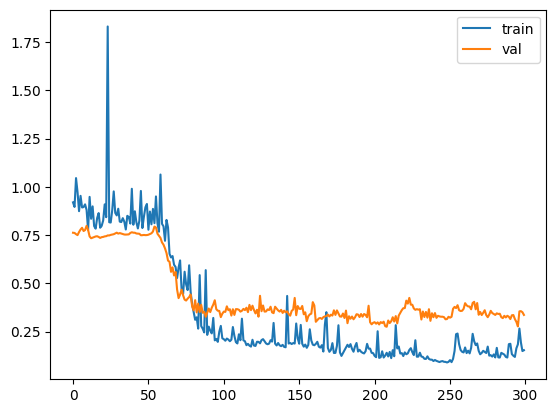

In [16]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [17]:
print_metrics(trained_model, test_dataloader)


Metrics with 95% confidence intervals:
RMSE: 42.31 ± 7.79
MAE: 27.10 ± 4.55
R2: 0.49 ± 0.19
MAE Median: 16.97 ± 3.98


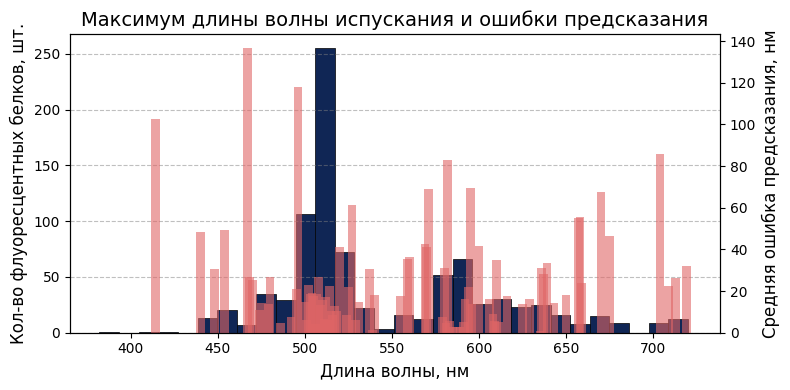

In [ ]:
import matplotlib.pyplot as plt
import json

# Get model predictions on test set
y_pred = []
y_true = []

trained_model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        inputs = batch[0].to(device)
        labels = batch[1].to(device)
        
        outputs = trained_model(inputs)
        
        y_pred.extend(outputs.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

y_pred = np.array(y_pred)   
y_true = np.array(y_true)
y_pred = dataset.rescale_targets(y_pred, 'em_max')
y_true = dataset.rescale_targets(y_true, 'em_max')
# Calculate absolute errors
y_pred = list(y_pred)
y_true = list(y_true)

pl = {}
c = {}
for i in range(len(y_pred)):
    if float(y_true[i]) not in pl:
        pl[float(y_true[i])] = abs(float(y_pred[i]) - float(y_true[i]))
        c[float(y_true[i])] = 1
    else:
        pl[float(y_true[i])] += abs(float(y_pred[i]) - float(y_true[i]))
        c[float(y_true[i])] += 1

for i in pl:
    pl[i] = pl[i] / c[i]

plt.rcParams['font.family'] = 'Arial'
SMALL_SIZE = 10
MEDIUM_SIZE = 12
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=MEDIUM_SIZE, labelsize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=MEDIUM_SIZE)

sns.set_theme(style='whitegrid')
plt.style.use('default')

main_color = '#102655'
with open('data/fpbase.json', 'r') as file:
    json_data = json.load(file)
em_max = []
for item in json_data:
    for state in item.get('states', []):
        if state.get('em_max') is not None and state.get('em_max') < 800:
            em_max.append(state['em_max'])

plt.figure(figsize=(8, 4))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot histogram on primary y-axis
n, bins, patches = ax1.hist(em_max, bins=30, color=main_color, edgecolor='black', 
                           linewidth=0.5, zorder=-1, alpha=1, label='Количество белков')

# Plot error bars on secondary y-axis
ax2.bar(pl.keys(), pl.values(), color='#e06666', alpha=0.6, width=5, label='Средняя ошибка')

ax1.set_xlabel('Длина волны, нм', fontsize=12)
ax1.set_ylabel('Кол-во флуоресцентных белков, шт.', fontsize=12)
ax2.set_ylabel('Средняя ошибка предсказания, нм', fontsize=12)

ax1.grid(axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)

# Add legends for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.title('Максимум длины волны испускания и ошибки предсказания', fontsize=14)
plt.tight_layout()
plt.show()

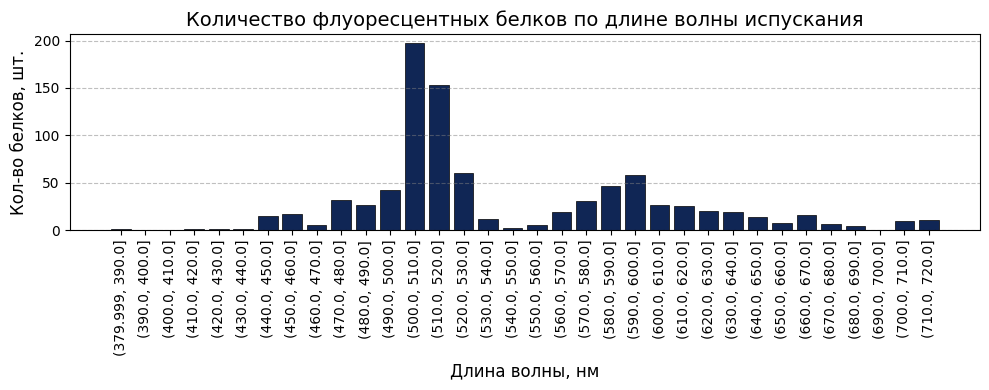

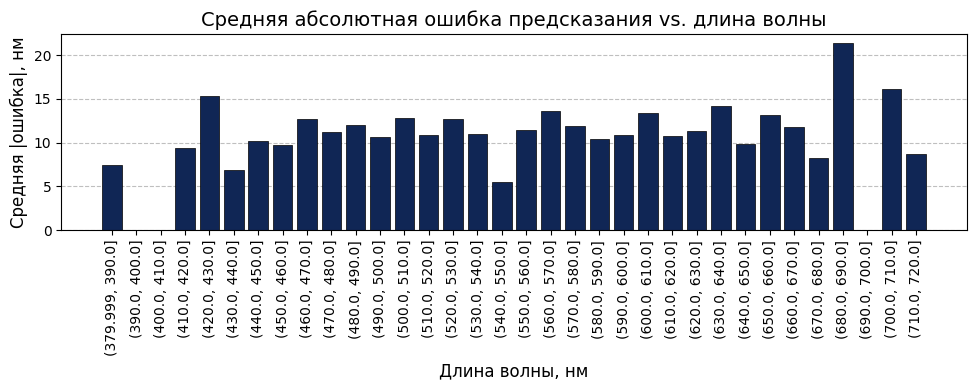

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Загрузка «истинных» значений длины волны
# ------------------------------------------------------------------
with open('data/fpbase.json', encoding='utf-8') as f:
    json_data = json.load(f)

em_max_true = []
for item in json_data:
    for state in item.get('states', []):
        if state.get('em_max') is not None and state.get('em_max') < 800:
            em_max_true.append(state['em_max'])
em_max_true = np.array(em_max_true)

# ------------------------------------------------------------------
# 2. Подготовка предсказаний модели
#    (y_pred_rescaled уже должен быть в нм; получите его из вашего
#    ноутбука с обучением/инференсом модели)
# ------------------------------------------------------------------
# Пример для иллюстрации. Замените на реальные предсказания:
# y_pred_rescaled = trained_model_predictions
rng = np.random.default_rng(42)
y_pred_rescaled = em_max_true + rng.normal(0, 15, size=len(em_max_true))  # DEMO ONLY

# ------------------------------------------------------------------
# 3. Подсчёт ошибок и биннинг по длине волны
# ------------------------------------------------------------------
errors = np.abs(y_pred_rescaled - em_max_true)

df = pd.DataFrame({
    'wavelength': em_max_true,
    'error': errors
})

# размер бина (нм)
BIN_WIDTH = 10
bins = np.arange(df['wavelength'].min() // BIN_WIDTH * BIN_WIDTH,
                 df['wavelength'].max() // BIN_WIDTH * BIN_WIDTH + BIN_WIDTH,
                 BIN_WIDTH)

df['bin'] = pd.cut(df['wavelength'], bins=bins, include_lowest=True)

# статистики по бинам
bin_stats = (
    df.groupby('bin')
      .agg(count=('error', 'size'),
           avg_error=('error', 'mean'))
      .reset_index()
)

# ------------------------------------------------------------------
# 4. Гистограмма количества ФП
# ------------------------------------------------------------------
main_color = '#102655'         # как в EDA-файле
plt.figure(figsize=(10, 4))
plt.grid(axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)

plt.bar(
    bin_stats['bin'].astype(str), bin_stats['count'],
    color=main_color, edgecolor='black', linewidth=0.5, zorder=1
)

plt.title('Количество флуоресцентных белков по длине волны испускания', fontsize=14)
plt.xlabel('Длина волны, нм', fontsize=12)
plt.ylabel('Кол-во белков, шт.', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. График средней абсолютной ошибки по бинам
# ------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.grid(axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)

plt.bar(
    bin_stats['bin'].astype(str), bin_stats['avg_error'],
    color=main_color, edgecolor='black', linewidth=0.5, zorder=2
)

plt.title('Средняя абсолютная ошибка предсказания vs. длина волны', fontsize=14)
plt.xlabel('Длина волны, нм', fontsize=12)
plt.ylabel('Средняя |ошибка|, нм', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
plot_error_analysis(trained_model, test_dataloader, dataset, TARGET_PROPERTY)

## EmbeddingLSTM

In [ ]:
model = EmbeddingLSTM(256).to(device)

trained_model, losses_train, losses_val = train_model(
    model, train_emb_dataloader, val_emb_dataloader
)

In [ ]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [ ]:
print_metrics(trained_model, test_emb_dataloader)

## SequenceCNN

In [20]:
model = SequenceCNN(
    len(VOCAB),
    embedding_dim=128,
    num_filters=64,
).to(device)

trained_model, losses_train, losses_val = train_model(
    model, train_dataloader, val_dataloader
)

100%|██████████| 300/300 [01:39<00:00,  3.00it/s]


In [21]:
torch.save(trained_model.state_dict(), "../../weights/SequenceCNN-full.pth")

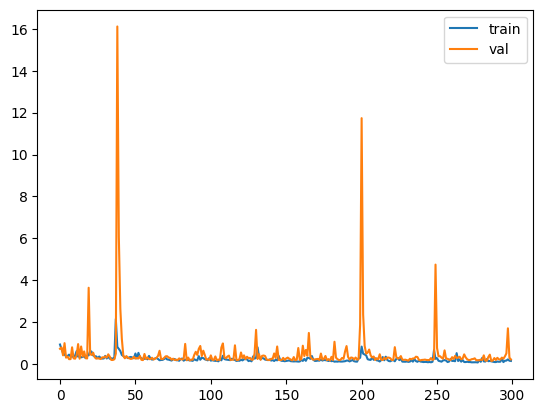

In [22]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [23]:
print_metrics(trained_model, test_dataloader)


Metrics with 95% confidence intervals:
RMSE: 41.85 ± 5.84
MAE: 31.20 ± 4.18
R2: 0.51 ± 0.15
MAE Median: 22.18 ± 3.32


## EmbeddingCNN

In [ ]:
model = EmbeddingCNN(num_filters=128).to(device)

trained_model, losses_train, losses_val = train_model(
    model, train_emb_dataloader, val_emb_dataloader
)

In [ ]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [ ]:
print_metrics(trained_model, test_emb_dataloader)

In [ ]:
model = SequenceLSTM(hidden_dim=128, num_layers=1, dropout=0.2).to(device)

trained_model, losses_train, losses_val = train_model(
    model, ac_train_dataloader, ac_val_dataloader
)

In [ ]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [ ]:
print_metrics(trained_model, ac_test_dataloader)

## ActiveCenterEmbeddingLSTM

In [ ]:
model = EmbeddingLSTM(hidden_size=256).to(device)

trained_model, losses_train, losses_val = train_model(
    model, ac_train_emb_dataloader, ac_val_emb_dataloader
)

In [ ]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [ ]:
print_metrics(trained_model, ac_test_emb_dataloader)

## ActiveCenterCNN

In [ ]:
model = SequenceCNN(embedding_dim=128, num_filters=256, dropout_rate=0.4).to(device)

trained_model, losses_train, losses_val = train_model(
    model, ac_train_dataloader, ac_val_dataloader
)

In [ ]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [ ]:
print_metrics(trained_model, ac_test_dataloader)

## ActiveCenterEmbeddingCNN

In [ ]:
model = EmbeddingCNN(num_filters=128).to(device)

trained_model, losses_train, losses_val = train_model(
    model, ac_train_emb_dataloader, ac_val_emb_dataloader
)

In [ ]:
plt.plot(losses_train)
plt.plot(losses_val)
plt.legend(loc='upper right', labels=['train', 'val'])
plt.show()

In [ ]:
from torchinfo import summary

model = EmbeddingLSTM(256)
summary(model, input_size=(32, (11, 12)), dtypes=[torch.long])

In [ ]:
print_metrics(trained_model, ac_test_emb_dataloader)

## Вывод архитектуры (torchinfo summary)

In [ ]:
from torchinfo import summary
import torch

def print_model_summary(model_name, model, is_embedding_model=False):
    print(f'\n{'='*50}')
    print(f'{model_name} Architecture:')
    print(f'{'='*50}')
    
    batch_size = 32
    seq_length = 100
    
    if is_embedding_model:
        # For embedding models, input is (batch_size, seq_length, embedding_dim)
        input_data = torch.randn(batch_size, seq_length, 960).to(device)
        print(summary(model, 
                input_data=input_data,
                col_names=['input_size', 'output_size'],
                col_width=20,
                row_settings=['var_names']))
    else:
        # For sequence models, input is (batch_size, seq_length)
        input_data = torch.randint(0, 21, (batch_size, seq_length)).to(device)
        print(summary(model, 
                input_data=input_data,
                col_names=['input_size', 'output_size'],
                col_width=20,
                row_settings=['var_names']))

print('Model Architectures Summary')
print('Each model will be shown with:')
print('- Layer structure')
print('- Input/output shapes')
print('- Number of parameters')
print('- Computational complexity (mult-adds)')
print('\nNote: Using batch_size=32 for demonstration')

# 1. Regular LSTM
model = SequenceLSTM(128).to(device)
print_model_summary('SequenceLSTM', model)

# 2. Embedding LSTM
model = EmbeddingLSTM(256).to(device)
print_model_summary('EmbeddingLSTM', model, is_embedding_model=True)

# 3. Regular CNN
model = SequenceCNN(embedding_dim=128, num_filters=64).to(device)
print_model_summary('SequenceCNN', model)

# 4. Embedding CNN
model = EmbeddingCNN(num_filters=128).to(device)
print_model_summary('EmbeddingCNN', model, is_embedding_model=True)

# 5. Active Center LSTM
model = ActiveCenterLSTM(hidden_dim=128, dropout=0.2).to(device)
print_model_summary('ActiveCenterLSTM', model)

# 6. Active Center Embedding LSTM
model = EmbeddingLSTM(hidden_size=256).to(device)
print_model_summary('ActiveCenterEmbeddingLSTM', model, is_embedding_model=True)

# 7. Active Center CNN
model = SequenceCNN(embedding_dim=128, num_filters=256, dropout_rate=0.4).to(device)
print_model_summary('ActiveCenterCNN', model)

# 8. Active Center Embedding CNN
model = EmbeddingCNN(num_filters=128).to(device)
print_model_summary('ActiveCenterEmbeddingCNN', model, is_embedding_model=True)

## Экспорт в .onnx для визуализации

In [ ]:
import torch.onnx
import os

# Create models directory in the project root
models_dir = os.path.join(os.getcwd(), 'models')
os.makedirs(models_dir, exist_ok=True)

def export_model_to_onnx(model, model_name, is_embedding_model=False):
    model.eval()
    
    # Create dummy input based on model type
    if is_embedding_model:
        dummy_input = torch.randn(1, 100, 960, device=device)  # [batch_size, seq_len, embedding_dim]
        input_names = ['embedding_input']
    else:
        dummy_input = torch.randint(0, 21, (1, 100), device=device)  # [batch_size, seq_len]
        input_names = ['sequence_input']
    
    # Define dynamic axes for variable sequence length
    dynamic_axes = {
        input_names[0]: {0: 'batch_size', 1: 'sequence_length'},
        'output': {0: 'batch_size'}
    }
    
    # Export the model using absolute path
    output_path = os.path.join(models_dir, f'{model_name}.onnx')
    torch.onnx.export(model,                     # model being run
                     (dummy_input,),             # model input as tuple
                     output_path,                # output path
                     export_params=True,         # store trained parameter weights
                     opset_version=11,           # ONNX version
                     do_constant_folding=True,   # optimize constant folding
                     input_names=input_names,    # model input names
                     output_names=['output'],    # model output names
                     dynamic_axes=dynamic_axes)  # variable length axes
    print(f'Exported {model_name} to {output_path}')

# 1. Regular LSTM
model = SequenceLSTM(128).to(device)
export_model_to_onnx(model, 'sequence_lstm')

# 2. Embedding LSTM
model = EmbeddingLSTM(256).to(device)
export_model_to_onnx(model, 'embedding_lstm', is_embedding_model=True)

# 3. Regular CNN
model = SequenceCNN(embedding_dim=128, num_filters=64).to(device)
export_model_to_onnx(model, 'sequence_cnn')

# 4. Embedding CNN
model = EmbeddingCNN(num_filters=128).to(device)
export_model_to_onnx(model, 'embedding_cnn', is_embedding_model=True)

# 5. Active Center LSTM
model = ActiveCenterLSTM(hidden_dim=128, dropout=0.2).to(device)
export_model_to_onnx(model, 'active_center_lstm')

# 6. Active Center Embedding LSTM
model = EmbeddingLSTM(hidden_size=256).to(device)
export_model_to_onnx(model, 'active_center_embedding_lstm', is_embedding_model=True)

# 7. Active Center CNN
model = SequenceCNN(embedding_dim=128, num_filters=256, dropout_rate=0.4).to(device)
export_model_to_onnx(model, 'active_center_cnn')

# 8. Active Center Embedding CNN
model = EmbeddingCNN(num_filters=128).to(device)
export_model_to_onnx(model, 'active_center_embedding_cnn', is_embedding_model=True)

print('All models exported successfully!')
